# Strategic Resource Optimization: Chicago Crime Analysis (2026)
**Course:** DSA 1080B – Programming for Data Science

**Author:** Anthony Ogolla – 676933

---

## Notebook Overview
This notebook presents a full data science pipeline applied to the City of Chicago's 2026 crime dataset — from raw data ingestion and cleaning through to exploratory analysis and deeper strategic insights.

## Dataset
- **Source:** City of Chicago Data Portal — Crimes 2026
- **Size:** 36,000+ recorded incidents (Q1 2026)
- **Key Variables:** Crime type, arrest status, district, location description, date/time

## Objectives
1. Clean and standardize the raw dataset for analysis
2. Identify temporal patterns in crime frequency to pinpoint peak demand windows
3. Measure arrest efficiency (arrest rate %) as the primary KPI across crime types and districts
4. Segment crimes by location type to differentiate deterrence vs. investigative resource needs
5. Produce a district-level efficiency ranking to identify resource saturation points

In [1]:
# WEEK 2 : LOADING & CLEANING DATASET

import pandas as pd
data = pd.read_csv('data/Crimes_-_2026_20260317.csv')
data.head()
data.info()

# 1.Converting Date to a proper datetime format
data['Date'] = pd.to_datetime(data['Date'], format = '%m/%d/%Y %I:%M:%S %p')

# 2.Handling missing values in Location Description
data['Location Description'] = data['Location Description'].fillna('UNKNOWN')

# 3.Droping rows where coordinates are missing
data.dropna(subset = ['Latitude', 'Location'], inplace = True)

# 4.Checking and removing duplicates
data.drop_duplicates(subset='ID', inplace = True)

# 5.Creating more specific columns for in-depth analysis
data['Hour'] = data['Date'].dt.hour
data['Day'] = data['Date'].dt.day_name()
data['Month'] = data['Date'].dt.month

# Confirming changes
data.info()
# Saving cleaned dataset
data.to_csv('data/cleaned_dataset.csv', index = False)


<class 'pandas.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    36520 non-null  int64  
 1   Case Number           36520 non-null  str    
 2   Date                  36520 non-null  str    
 3   Block                 36520 non-null  str    
 4   IUCR                  36520 non-null  str    
 5   Primary Type          36520 non-null  str    
 6   Description           36520 non-null  str    
 7   Location Description  36344 non-null  str    
 8   Arrest                36520 non-null  bool   
 9   Domestic              36520 non-null  bool   
 10  Beat                  36520 non-null  int64  
 11  District              36520 non-null  int64  
 12  Ward                  36520 non-null  int64  
 13  Community Area        36520 non-null  int64  
 14  FBI Code              36520 non-null  str    
 15  X Coordinate          36469 no

In [2]:
# WEEK 3 : EXPLORATORY DATA ANALYSIS
# Setting visual style
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

data = pd.read_csv('data/cleaned_dataset.csv')

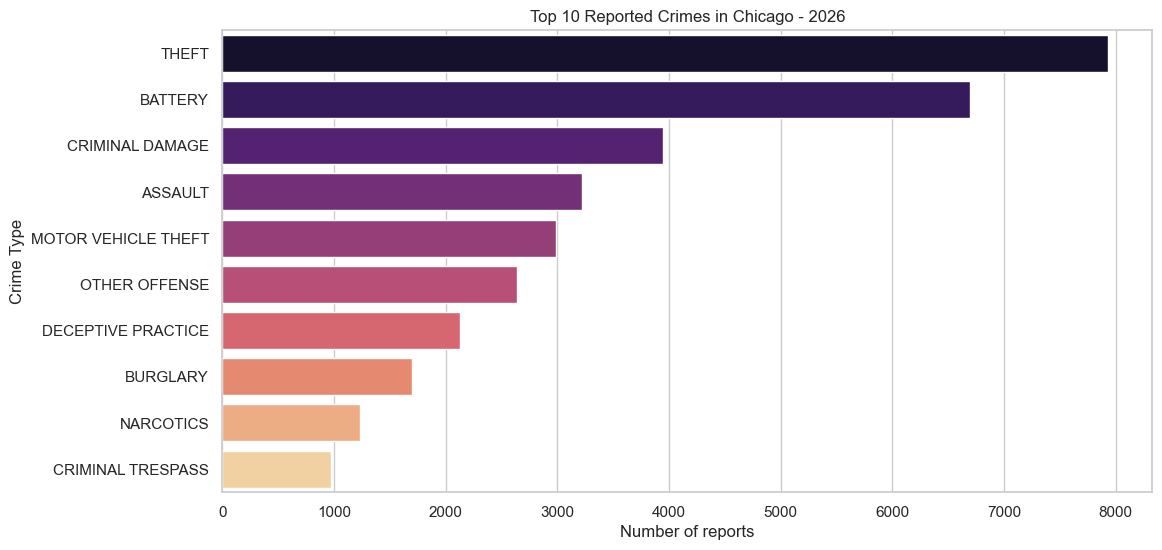

In [3]:
# Insight 1 : Top 10 crime types
top_10_crimes = data['Primary Type'].value_counts().head(10)

sns.barplot(x=top_10_crimes.values, y=top_10_crimes.index, hue=top_10_crimes.index, palette='magma', legend=False)
plt.title('Top 10 Reported Crimes in Chicago - 2026')
plt.xlabel('Number of reports')
plt.ylabel('Crime Type')

plt.savefig('visuals/top_10_crimes.png', bbox_inches='tight')
plt.show()

**Interpretation:** This chart establishes the volume of demand across different categories. Theft and Battery emerge as the primary drivers of police activity in 2026. From an optimization perspective, this indicates that the 'Generalist' patrol officer must be most proficient in these two areas, as they represent the highest probability of daily encounter.

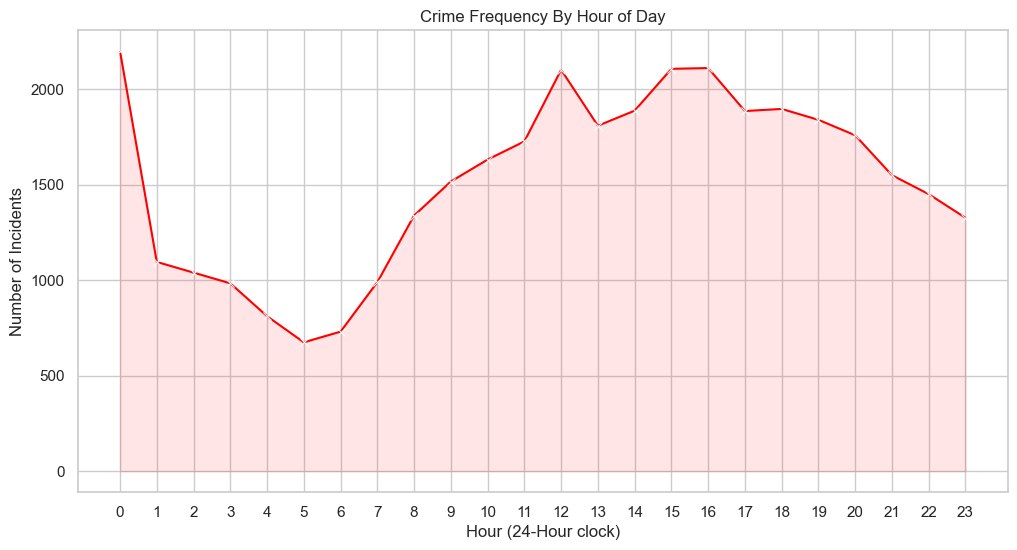

In [4]:
# Insight 2 : Hourly Distribution of Crimes
hourly_counts = data.groupby('Hour').size()

sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker = 'x', color = 'red')
plt.fill_between(hourly_counts.index, hourly_counts.values, color = 'red', alpha = 0.1)
plt.xticks(range(0, 24))
plt.title('Crime Frequency By Hour of Day')
plt.xlabel('Hour (24-Hour clock)')
plt.ylabel('Number of Incidents')

plt.savefig('visuals/hourly_distribution.png')

**Interpretation:** This visualization identifies the daily "peak load" for the Chicago Police Department. We see a sharp upward trend starting at 06:00, with major surges occurring around noon and again in the late afternoon (15:00)

<function matplotlib.pyplot.show(close=None, block=None)>

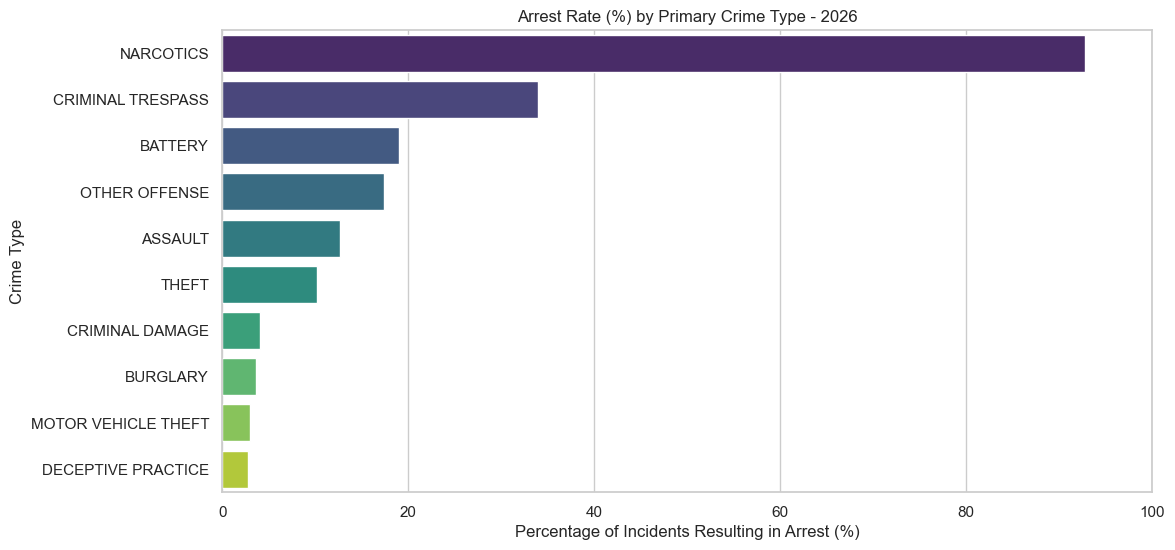

In [5]:
# Insight 3 : Arrest Rates by Category
top_crimes = data['Primary Type'].value_counts().head(10).index
arrest_data = data[data['Primary Type'].isin(top_crimes)]

arrest_rate = (arrest_data.groupby('Primary Type')['Arrest'].mean() * 100).sort_values(ascending = False)

sns.barplot(x=arrest_rate.values, y=arrest_rate.index, hue=arrest_rate.index, palette='viridis')
plt.title('Arrest Rate (%) by Primary Crime Type - 2026')
plt.xlabel('Percentage of Incidents Resulting in Arrest (%)')
plt.ylabel('Crime Type')
plt.xlim(0, 100)

plt.savefig('visuals/arrest_rate_by_crime.png', bbox_inches='tight')
plt.show

**Interpretation:** There is a big difference in arrest rates across crime categories. While narcotics offenses show an arrest rate near 90%, theft and burglary are below 10%.
 This indicates that crimes police see happening, like drug deals, are much easier to clear than crimes reported after their occurence such as break-ins.

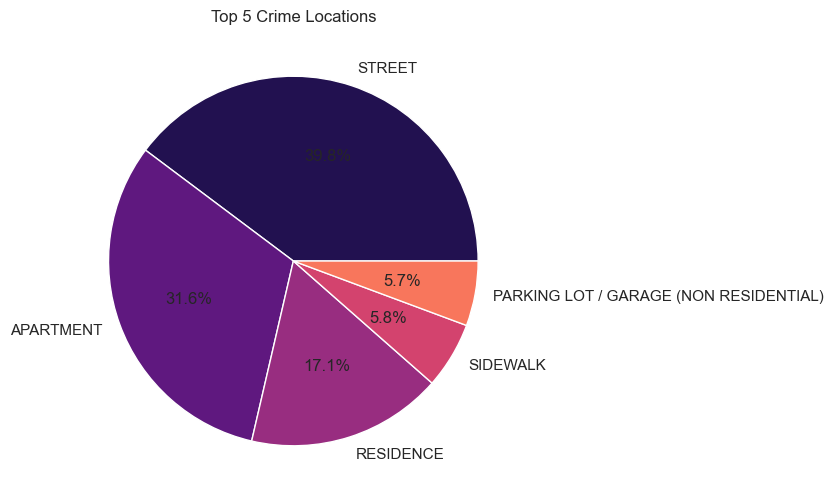

In [6]:
# Insight 4 - Location Analysis
top_locations = data['Location Description'].value_counts().head(5)

plt.figure(figsize=(10, 6))
plt.pie(top_locations, labels=top_locations.index, autopct='%1.1f%%', colors=sns.color_palette('magma'))
plt.title('Top 5 Crime Locations')

plt.savefig('visuals/top_locations.png')
plt.show()

**Interpretation**: Chart shows a high number of crimes in the streets followed by apartments This shows that increased street patrols would prove very useful in deterring street crimes which has proven to be prevalent relative to the rest. Addressing battery and domestic incidents requires targeted community-based intervention rather than just increased police visibility on sidewalks.

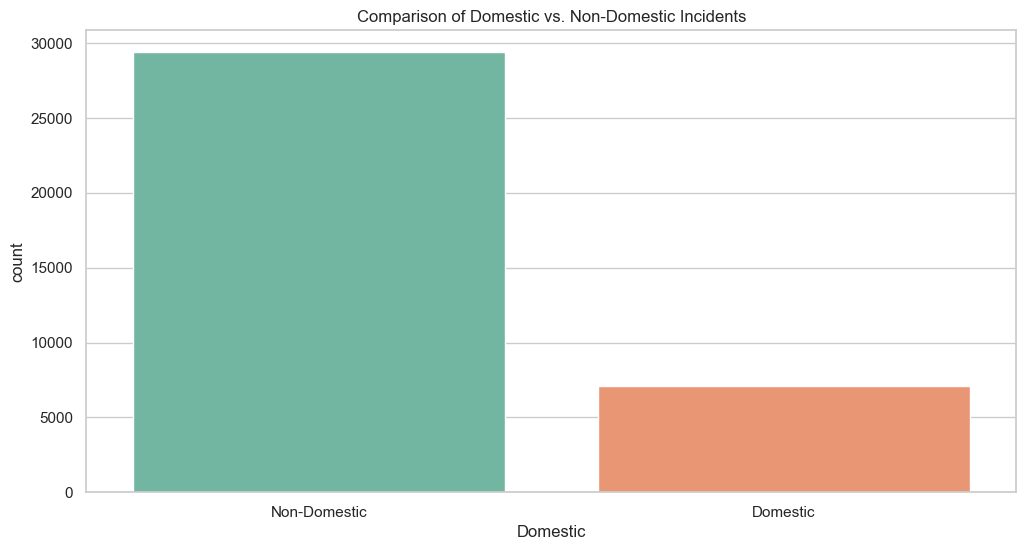

In [7]:
# Insight 5 : Domestic vs Non-Domestic Analysis
sns.countplot(data=data, x='Domestic', hue='Domestic', palette='Set2', legend=False)
plt.title('Comparison of Domestic vs. Non-Domestic Incidents')
plt.xticks([0, 1], ['Non-Domestic', 'Domestic'])

plt.savefig('visuals/domestic_ratio.png')
plt.show()

**Interpretation:** Non-domestic oncidents outnumber domestic ones by roughly 5:1. This shows that criminal activity is mainly tied to encounters with strangers rather than in the household.

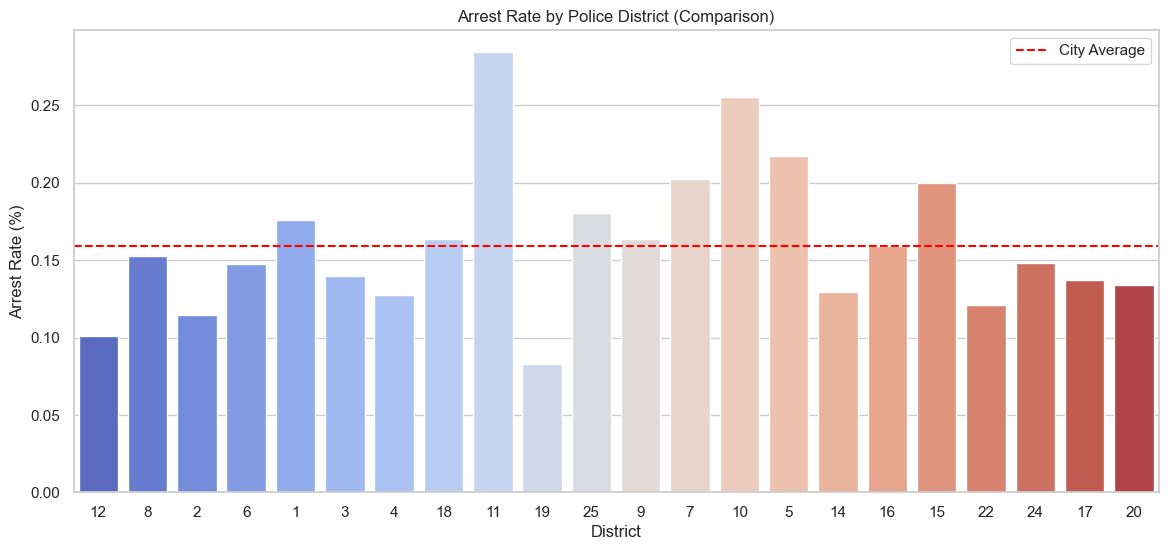

In [8]:
#WEEK 4 --DEEPER ANALYSIS--
# Deeper analysis by District to see arrest distribution
district_analysis = data.groupby('District').agg({
    'ID': 'count',
    'Arrest': 'mean'
}).rename(columns={'ID': 'Total Crimes', 'Arrest': 'Arrest Rate'})

# Sort by crime volume
district_analysis = district_analysis.sort_values(by='Total Crimes', ascending=False)

# Visualization
plt.figure(figsize=(14, 6))
sns.barplot(x=district_analysis.index.astype(str), y=district_analysis['Arrest Rate'],hue=district_analysis.index.astype(str), palette='coolwarm')
plt.axhline(data['Arrest'].mean(), color='red', linestyle='--', label='City Average')
plt.title('Arrest Rate by Police District (Comparison)')
plt.ylabel('Arrest Rate (%)')
plt.legend()
plt.savefig('visuals/district_comparison.png')
plt.show()

**Interpretation:** By adding the red "City Average" line (approx. 16%), one can immediately distinguish between over-performers and under-performers. Districts like 11, 10, and 5 are pulling the city average up, while a majority of districts sit just below the line.

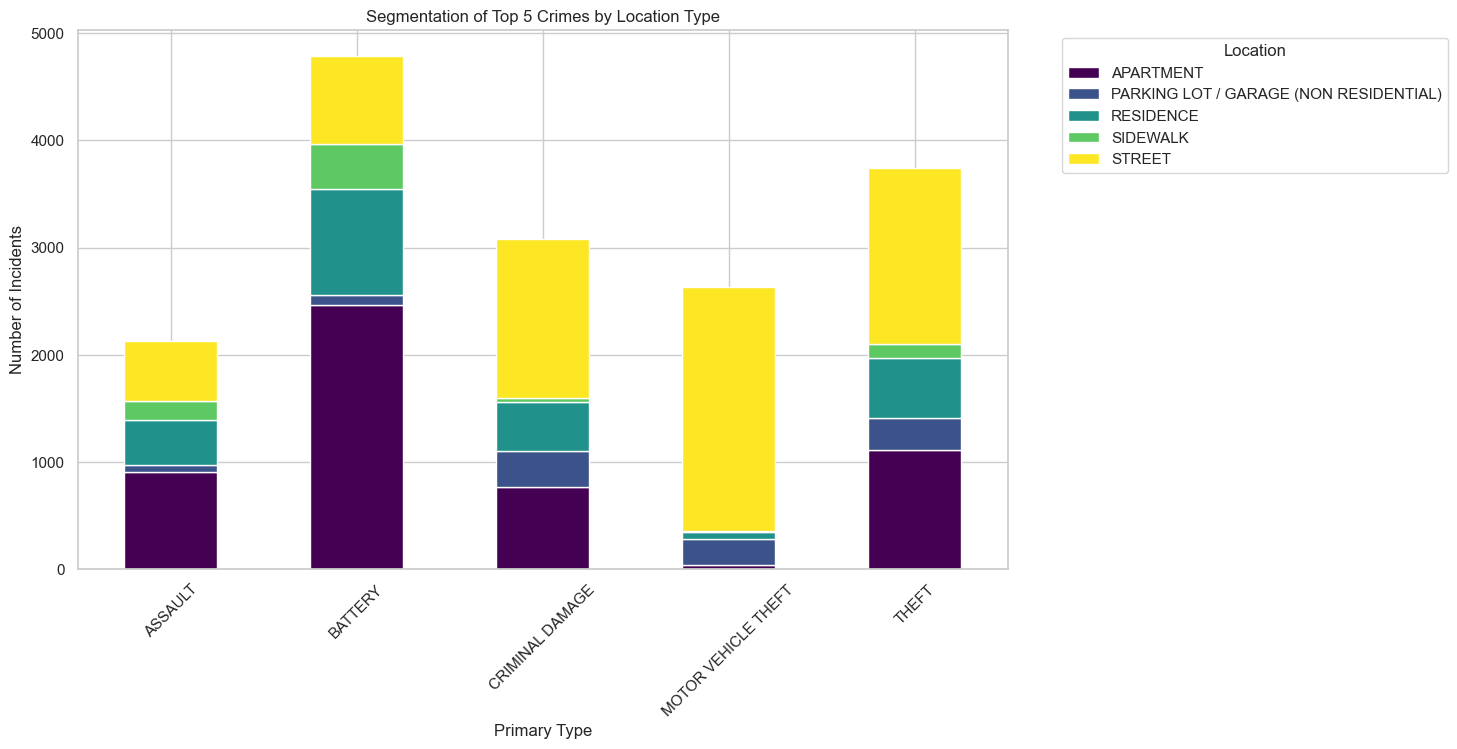

In [9]:
#Deeper analysis by segmentation
# Filter for top categories
top_crimes = data['Primary Type'].value_counts().head(5).index
top_locs = data['Location Description'].value_counts().head(5).index

# Subset the data
segmented_df = data[data['Primary Type'].isin(top_crimes) & data['Location Description'].isin(top_locs)]

# Create a pivot table for the segment visualization
pivot_data = segmented_df.groupby(['Primary Type', 'Location Description']).size().unstack().fillna(0)

# Plotting a stacked bar chart for segmentation
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Segmentation of Top 5 Crimes by Location Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('visuals/crime_location_segmentation.png', bbox_inches='tight')
plt.show()


**Interpretation:** This chart reveals where different crimes are physically concentrated. While Motor Vehicle Theft and Theft are overwhelmingly public-space crimes (Street), Battery is uniquely concentrated in private "Apartments."

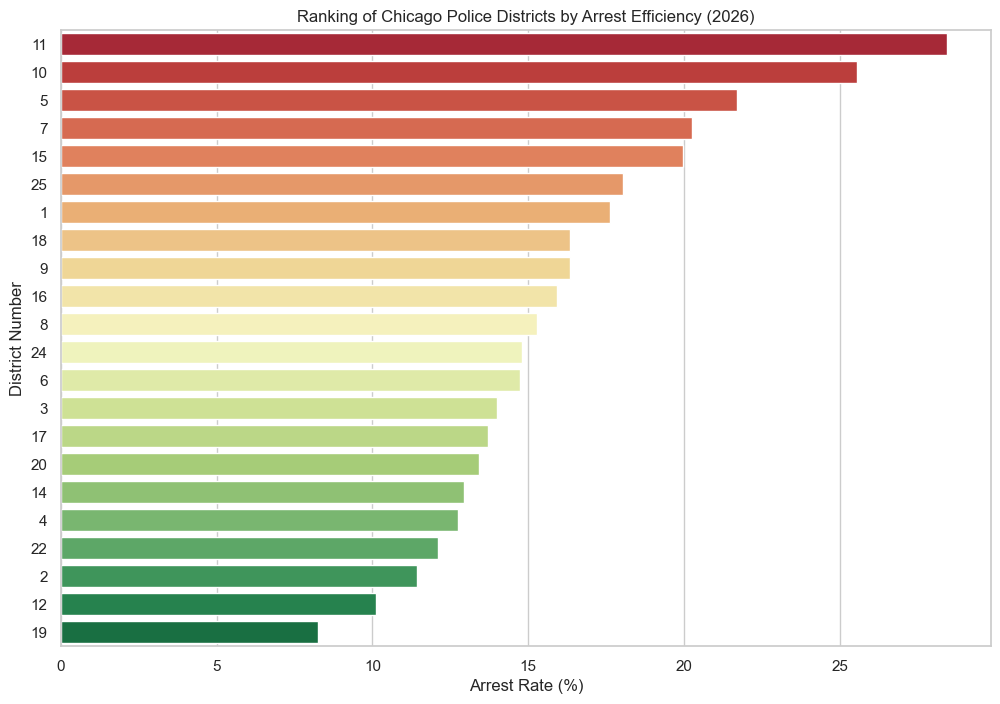

In [10]:
#Deeper analysis by ranking
# total crimes and arrest rate per district
district_rank = data.groupby('District').agg(
    total_crimes=('ID', 'count'),
    arrest_rate=('Arrest', 'mean')
).reset_index()

# Converting arrest rate to percentage
district_rank['arrest_rate'] *= 100

# Ranking them by Arrest Rate (Highest to Lowest)
district_rank = district_rank.sort_values(by='arrest_rate', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=district_rank, x='arrest_rate', y=district_rank['District'].astype(str), hue=district_rank['District'].astype(str), palette='RdYlGn')
plt.title('Ranking of Chicago Police Districts by Arrest Efficiency (2026)')
plt.xlabel('Arrest Rate (%)')
plt.ylabel('District Number')

plt.savefig('visuals/district_efficiency_ranking.png')
plt.show()

**Interpretation:** This is the primary KPI chart, ranking districts by their Arrest Rate %. We see a drastic range—from District 11 at nearly 30% efficiency to District 19 at under 10%.

## Summary and Conclusions

This analysis confirms that criminal activity in Chicago follows clear, predictable patterns 
that can directly inform resource allocation decisions.

Three findings stand out. First, crime frequency peaks sharply around noon and again 
in the mid-to-late afternoon, meaning current static shift models leave the highest-demand 
window underserved. Second, the district efficiency ranking reveals a significant gap — 
District 11 clears nearly 30% of incidents while District 19 clears under 10% — suggesting 
resource saturation rather than a shortage of personnel citywide. Third, the stark contrast 
between narcotics arrest rates (~90%) and theft arrest rates (~10%) exposes a specialization 
gap: reactive models struggle with property crimes reported after the fact.

Together these findings support a shift toward a dynamic, data-driven deployment model 
that reallocates resources by time, location type, and district efficiency — without 
requiring any increase in budget or headcount.